
# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/Central_Thailand_TIF.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("meta data from Raster:")
    print(dataset.meta)


meta data from Raster:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 4017, 'height': 4889, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0008983152841195215, 0.0, 98.18316560841134,
       0.0, -0.0008983152841195215, 17.81718534522659)}



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


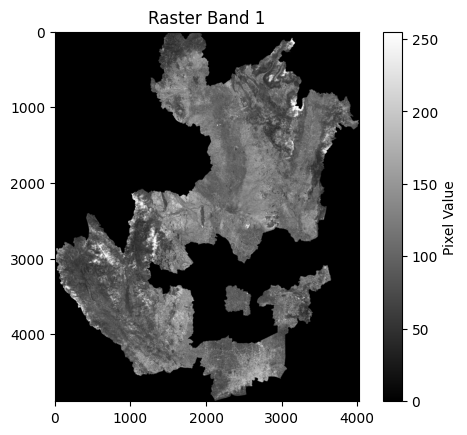

In [3]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


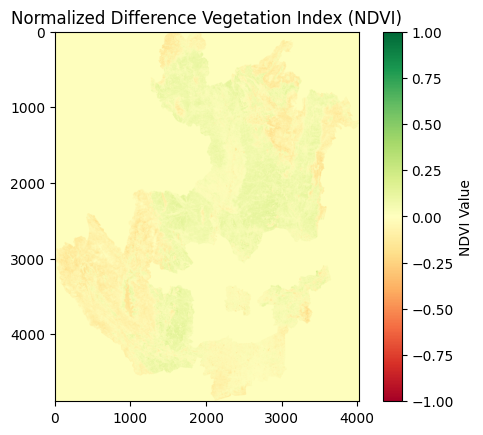

In [4]:

import numpy as np

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    nir = dataset.read(1).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(2).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [5]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")


บันทึกไฟล์ NDVI เรียบร้อย!



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [41]:
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import rasterio

# 1. ระบุพาธไฟล์ (เช็คชื่อไฟล์ .shp ให้ตรง)
shapefile_path = "/content/drive/MyDrive/thailand"

# 2. โหลดข้อมูล
gdf = gpd.read_file(shapefile_path)

# 3. กรองเพื่อเลือกขอบเขตของ "จังหวัดปทุมธานี"
# ลองใช้ 'PATHUM THANI' (ตัวพิมพ์ใหญ่) หรือถ้าไม่พบให้เช็คจากคำสั่ง print(gdf['PROVINCE_E'].unique())
target_province = 'PATHUM THANI'
pathum_boundary = gdf[gdf['PROVINCE_E'] == target_province]

# กรณีหาไม่เจอ ให้ลองดัก Error ไว้
if pathum_boundary.empty:
    print("ไม่พบชื่อ PATHUM THANI ลองตรวจสอบการสะกดใหม่...")
    print("รายชื่อจังหวัดที่มี:", gdf['PROVINCE_E'].unique())
    raise ValueError(f"ไม่พบขอบเขตของจังหวัด {target_province}")

# 4. เตรียม Geometry สำหรับตัด
geometry = [mapping(pathum_boundary.geometry.iloc[0])]

# 5. เปิดภาพ Raster และทำการตัด (Clip)
with rasterio.open(raster_path) as src:
    # ตรวจสอบและ Re-project CRS ให้ตรงกัน
    if src.crs != pathum_boundary.crs:
        print(f"กำลังแปลงพิกัดจาก {pathum_boundary.crs} เป็น {src.crs}...")
        pathum_boundary = pathum_boundary.to_crs(src.crs)
        geometry = [mapping(pathum_boundary.geometry.iloc[0])]

    # ตัดภาพ
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# 6. อัปเดตเมตาดาต้า
out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform,
    "nodata": 0 # กำหนดให้พื้นที่นอกขอบเขตเป็น 0 หรือ None
})

# 7. บันทึกไฟล์
clipped_raster = "/content/drive/MyDrive/thailand/pathum_clipped.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูลจังหวัดปทุมธานีสำเร็จ!")

กำลังแปลงพิกัดจาก EPSG:24047 เป็น EPSG:4326...
ตัดข้อมูลจังหวัดปทุมธานีสำเร็จ!



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


In [8]:
#
import rasterio

# เปิดไฟล์ Raster
raster_path = "/content/drive/MyDrive/Central_Thailand_TIF.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมต้า from Raster มาแล้วฮ้าฟบะบี๋:")
    print(dataset.meta)


ข้อมูลเมต้า from Raster มาแล้วฮ้าฟบะบี๋:
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 4017, 'height': 4889, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.0008983152841195215, 0.0, 98.18316560841134,
       0.0, -0.0008983152841195215, 17.81718534522659)}


**แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib**

ขนาดภาพ (Width, Height): 4017 x 4889
จำนวนแบนด์ทั้งหมด: 3
ระบบพิกัด (CRS): EPSG:4326


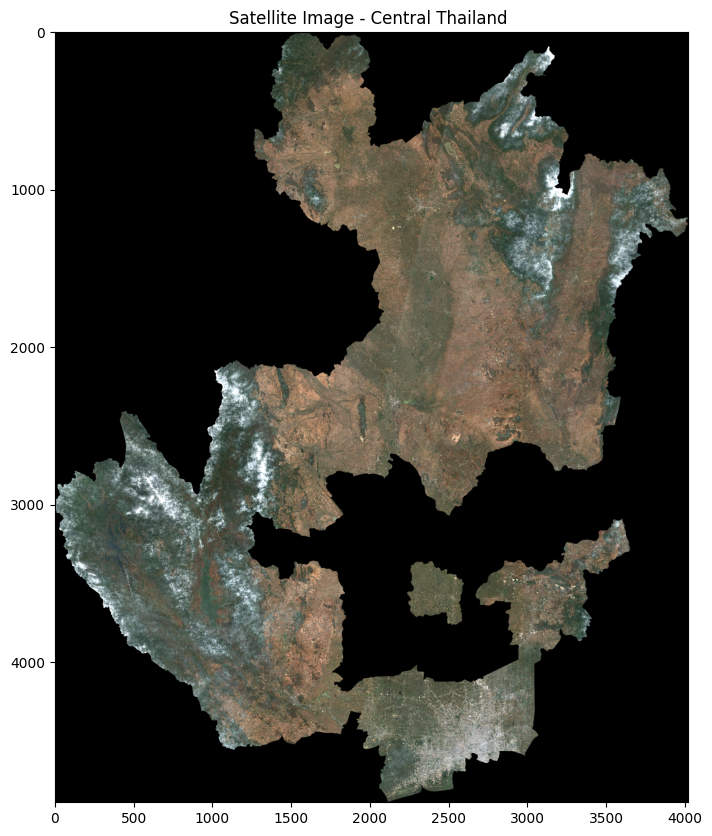

In [44]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# 1. กำหนดที่อยู่ของไฟล์ภาพดาวเทียม
raster_path = "/content/drive/MyDrive/Central_Thailand_TIF.tif"

# 2. ใช้ Rasterio เปิดอ่านไฟล์
with rasterio.open(raster_path) as src:
    # อ่านแบนด์ที่ 1, 2, 3 (Red, Green, Blue)
    # หมายเหตุ: .read() จะดึงข้อมูลออกมาเป็น numpy array
    red = src.read(1)
    green = src.read(2)
    blue = src.read(3)

    # แสดงข้อมูล Metadata เบื้องต้น
    print(f"ขนาดภาพ (Width, Height): {src.width} x {src.height}")
    print(f"จำนวนแบนด์ทั้งหมด: {src.count}")
    print(f"ระบบพิกัด (CRS): {src.crs}")

# 3. เตรียมข้อมูลสำหรับการแสดงผลภาพสีจริง (True Color RGB)
# เราต้องรวมแบนด์เข้าด้วยกัน และทำการ Normalize ค่าพิกเซล
def normalize(array):
    array_min, array_max = array.min(), array.max()
    return ((array - array_min) / (array_max - array_min))

rgb_image = np.dstack((normalize(red), normalize(green), normalize(blue)))

# 4. แสดงผลด้วย Matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(rgb_image)
plt.title("Satellite Image - Central Thailand ")
plt.axis('on') # ตัวเลขแกน x, y
plt.show()

**แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้**

In [47]:
import rasterio

# 1. ระบุพาธไฟล์
raster_path = "/content/drive/MyDrive/Central_Thailand_TIF.tif"

# 2. เปิดไฟล์และดึงค่า Metadata
with rasterio.open(raster_path) as src:
    meta = src.meta

    print("--- รายละเอียดข้อมูลเมตา (Raster Metadata) ---")
    for key, value in meta.items():
        print(f"{key}: {value}")

    print("\n--- ข้อมูลเพิ่มเติมที่สำคัญ ---")
    print(f"ขอบเขตภาพ (Bounds): {src.bounds}")
    print(f"หน่วยของระบบพิกัด: {src.crs.linear_units}")

--- รายละเอียดข้อมูลเมตา (Raster Metadata) ---
driver: GTiff
dtype: uint8
nodata: None
width: 4017
height: 4889
count: 3
crs: EPSG:4326
transform: | 0.00, 0.00, 98.18|
| 0.00,-0.00, 17.82|
| 0.00, 0.00, 1.00|

--- ข้อมูลเพิ่มเติมที่สำคัญ ---
ขอบเขตภาพ (Bounds): BoundingBox(left=98.18316560841134, bottom=13.425321921166251, right=101.79169810471946, top=17.81718534522659)
หน่วยของระบบพิกัด: unknown


**แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่**

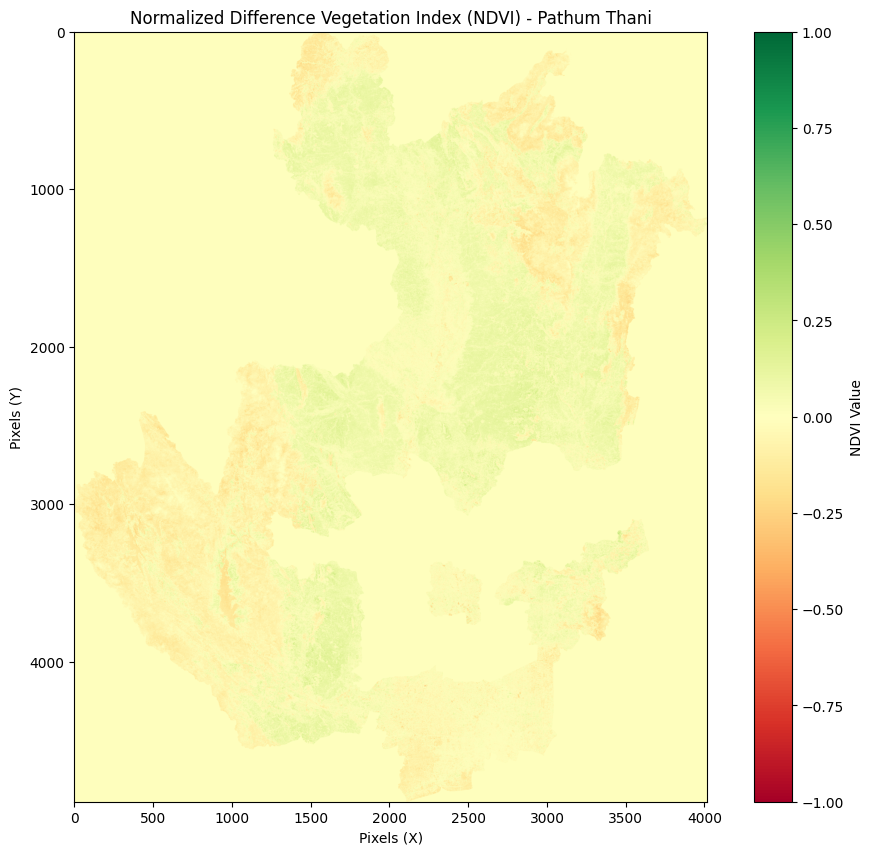

In [62]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 1. เปิดไฟล์ภาพ
# สมมติว่า Band 1 = NIR (B8) และ Band 2 = Red (B4) จากการ Export
raster_path = "/content/drive/MyDrive/Central_Thailand_TIF.tif"

with rasterio.open(raster_path) as src:
    # อ่านข้อมูลและแปลงเป็น float เพื่อให้คำนวณทศนิยมได้
    nir = src.read(1).astype('float32')
    red = src.read(2).astype('float32')

# 2. คำนวณ NDVI ด้วย NumPy
# ใช้ np.seterr เพื่อจัดการกรณีหารด้วยศูนย์
np.seterr(divide='ignore', invalid='ignore')

ndvi = (nir - red) / (nir + red)

# 3. จัดการค่าที่ผิดปกติ (เช่น NaN) ให้เป็น 0 หรือค่าที่เหมาะสม
ndvi = np.nan_to_num(ndvi)

# 4. แสดงผลแผนที่ NDVI
plt.figure(figsize=(12, 10))
img = plt.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1) # ใช้โทนสี แดง-เหลือง-เขียว
plt.colorbar(img, label='NDVI Value')

plt.title("Normalized Difference Vegetation Index (NDVI) - Pathum Thani")
plt.xlabel("Pixels (X)")
plt.ylabel("Pixels (Y)")
plt.show()

/tmp/ipykernel_35743/994185819.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  current_cmap = cm.get_cmap('RdYlGn').copy()


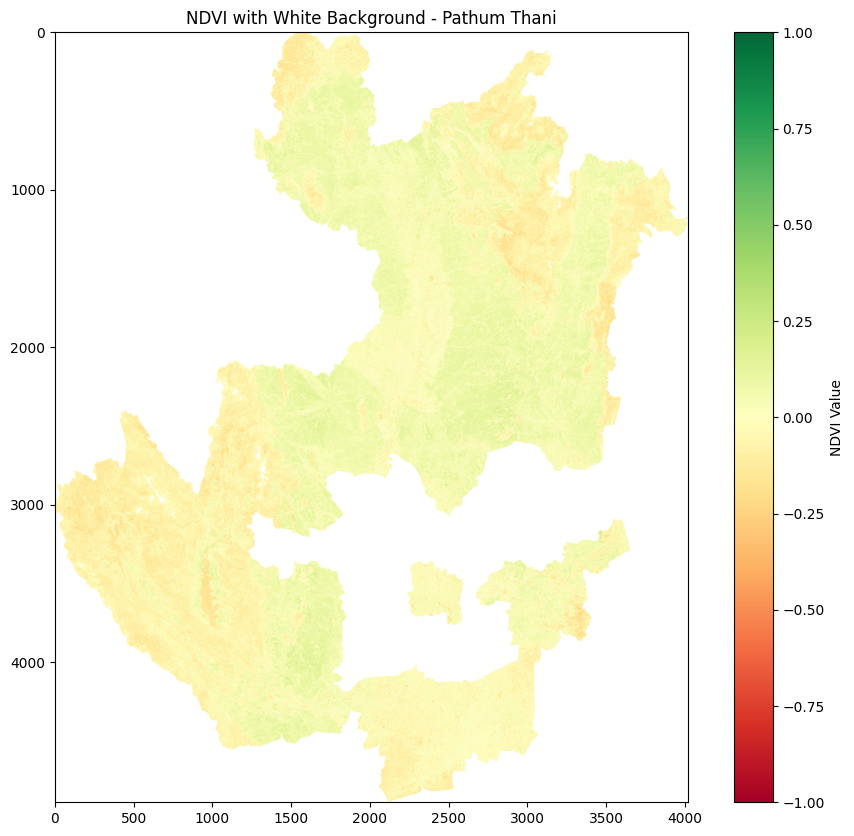

In [64]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ... (โค้ดส่วนการอ่านไฟล์และคำนวณ ndvi เหมือนเดิม) ...

# 1. เปลี่ยนค่า 0 (พื้นหลัง) ให้เป็น NaN
ndvi_masked = np.where(ndvi == 0, np.nan, ndvi)

# 2. ตั้งค่า Colormap ให้แสดงผลค่า NaN เป็นสีขาว
current_cmap = cm.get_cmap('RdYlGn').copy()
current_cmap.set_bad(color='white') # กำหนดให้ค่าที่เป็น NaN (หรือ 0 เดิม) เป็นสีขาว

# 3. แสดงผล
plt.figure(figsize=(12, 10))
# ใช้ ndvi_masked แทน ndvi และใส่ cmap ที่ตั้งค่าไว้
img = plt.imshow(ndvi_masked, cmap=current_cmap, vmin=-1, vmax=1)

plt.colorbar(img, label='NDVI Value')
plt.title("NDVI with White Background - Pathum Thani")
plt.axis('on')
plt.show()

**แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile**

ตัดข้อมูลสำเร็จ! บันทึกไฟล์ที่: /content/drive/MyDrive/thailand/pathum_clipped_final.tif


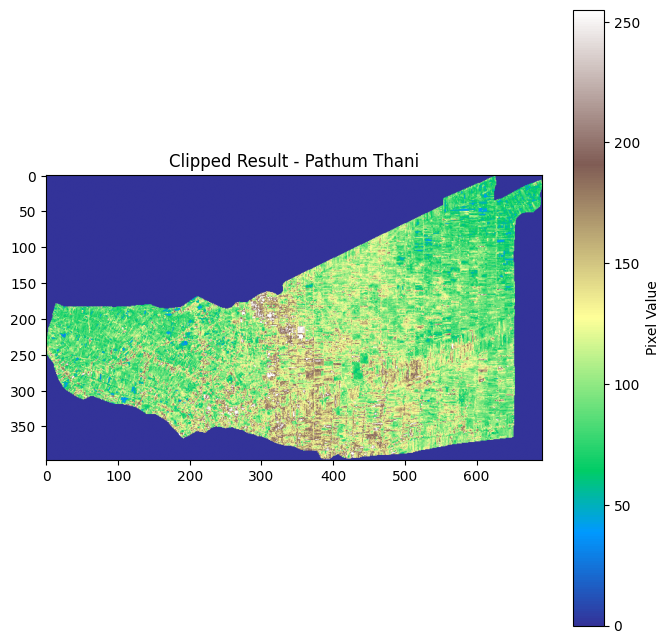

In [49]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt

# 1. กำหนด Path ไฟล์
raster_path = "/content/drive/MyDrive/Central_Thailand_TIF.tif"
shapefile_path = "/content/drive/MyDrive/thailand/Province.shp"

# 2. อ่านไฟล์ Shapefile และเลือกเฉพาะพื้นที่ที่ต้องการ
gdf = gpd.read_file(shapefile_path)
# กรองเอาเฉพาะจังหวัดปทุมธานี (เช็คชื่อคอลัมน์จากแบบฝึกหัดก่อนหน้า)
pathum_boundary = gdf[gdf['PROVINCE_E'] == 'PATHUM THANI']

# 3. เปิดไฟล์ Raster เพื่อเตรียมการตัด
with rasterio.open(raster_path) as src:
    # ⚠️ สำคัญ: ตรวจสอบและแปลงระบบพิกัด (CRS) ให้ตรงกัน
    if pathum_boundary.crs != src.crs:
        pathum_boundary = pathum_boundary.to_crs(src.crs)

    # แปลงขอบเขตจาก GeoDataFrame เป็นรูปแบบที่ rasterio เข้าใจ
    geoms = [mapping(row) for row in pathum_boundary.geometry]

    # สั่งตัดภาพด้วยคำสั่ง mask
    # crop=True หมายถึงการตัดขนาดไฟล์ให้เล็กลงเท่ากับขอบเขตที่ตัด (ไม่เก็บพื้นที่ว่างรอบนอก)
    out_image, out_transform = mask(src, geoms, crop=True)
    out_meta = src.meta.copy()

# 4. อัปเดตข้อมูลเมตา (Metadata) สำหรับไฟล์ที่ถูกตัดใหม่
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# 5. บันทึกผลลัพธ์เป็นไฟล์ใหม่
output_path = "/content/drive/MyDrive/thailand/pathum_clipped_final.tif"
with rasterio.open(output_path, "w", **out_meta) as dest:
    dest.write(out_image)

print(f"ตัดข้อมูลสำเร็จ! บันทึกไฟล์ที่: {output_path}")

# 6. แสดงผลตรวจสอบ
plt.figure(figsize=(8, 8))
plt.imshow(out_image[0], cmap='terrain')
plt.title("Clipped Result - Pathum Thani")
plt.colorbar(label='Pixel Value')
plt.show()